In [1]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 200

In [2]:
%load_ext autoreload
%autoreload 2

# Effective Equation of State from TIGRESS-classic and TIGRESS-NCR

In [3]:
import prfm

In [4]:
import xarray as xr
import numpy as np

In [5]:
classic_data = xr.open_dataset("../prfm/classic_eos.nc")
ncr_data = xr.open_dataset("../prfm/ncr_eos.nc")

(5, 60)

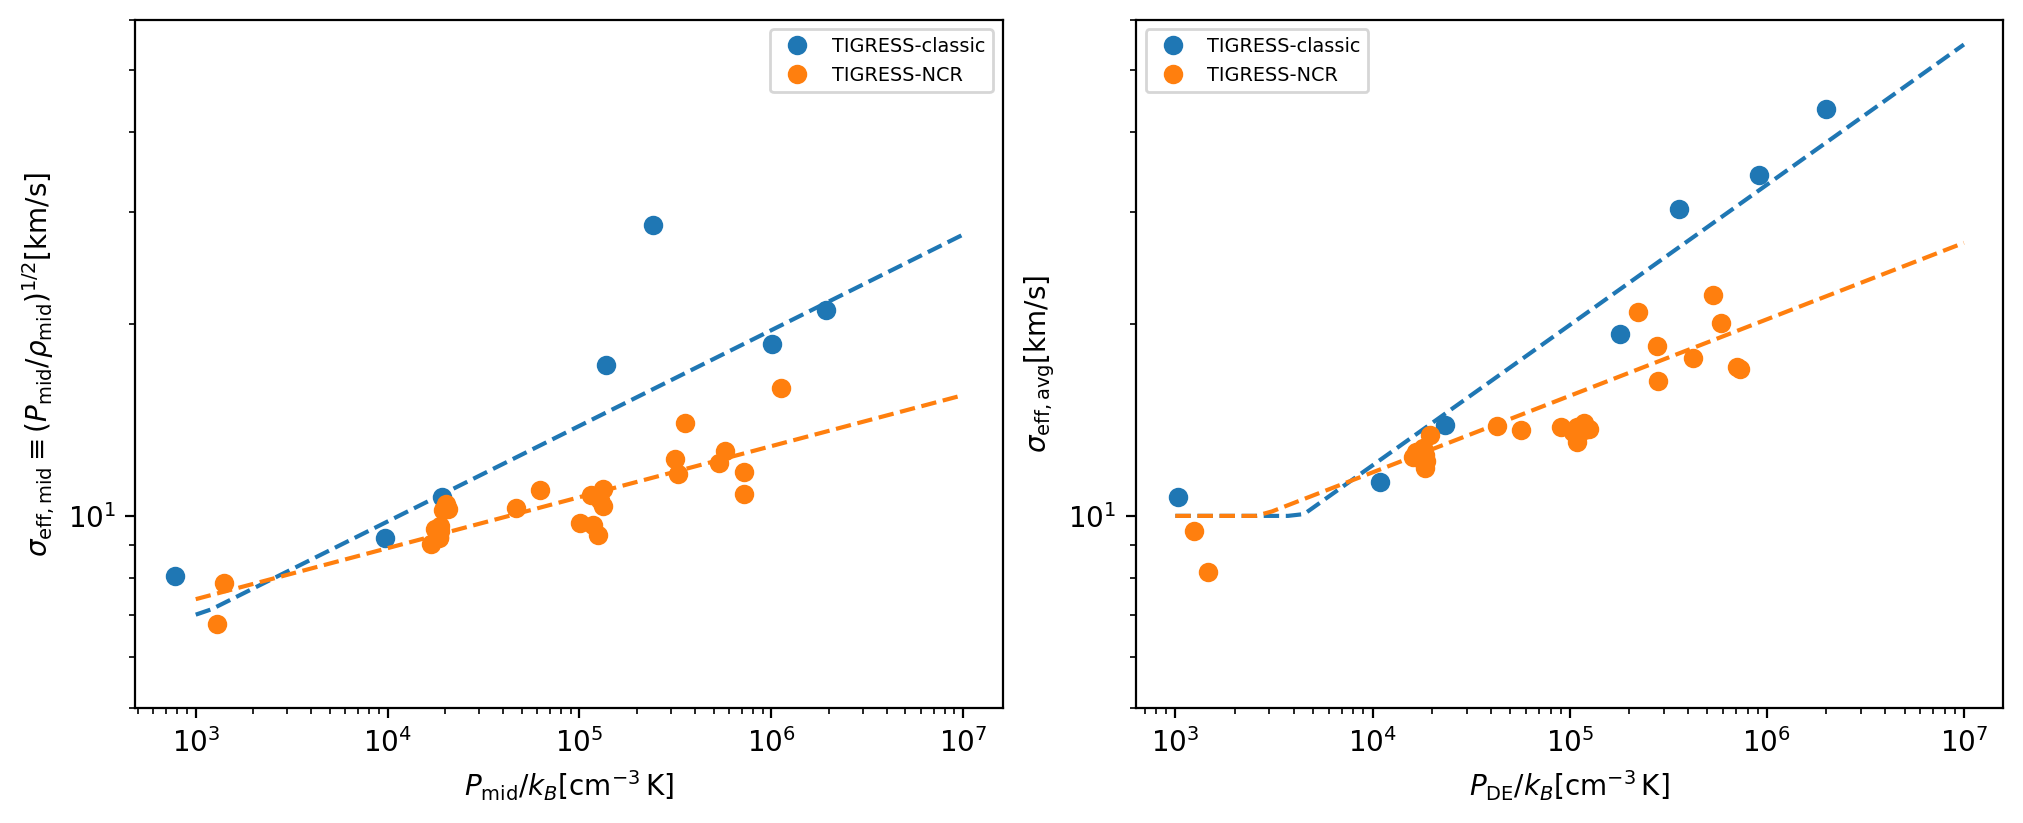

In [14]:
# sigma vs P
fig,axes = plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
PDEarr = np.logspace(3,7)
sigfit = dict()
for model in ["tigress-classic-avg", "tigress-ncr-avg",
              "tigress-classic-mid", "tigress-ncr-mid"]:
    sigfit[model] = prfm.get_sigma_eff(PDEarr*prfm.prfm._kbol_cgs,model=model)/1.e5

# midplane measures
plt.sca(axes[0])
plt.plot(classic_data["Pmid"], classic_data["sigma_mid"], "o", label="TIGRESS-classic")
plt.plot(PDEarr, sigfit["tigress-classic-mid"],
         ls="--", color="C0")
plt.plot(ncr_data["Pmid"], ncr_data["sigma_mid"], "o", label="TIGRESS-NCR")
plt.plot(PDEarr, sigfit["tigress-ncr-mid"],
         ls="--", color="C1")
plt.legend(fontsize="x-small")
plt.ylabel(r"$\sigma_{\rm eff,mid} \equiv (P_{\rm mid}/\rho_{\rm mid})^{1/2} [{\rm km/s}]$")
plt.xlabel(r"$P_{\rm mid}/k_B [{\rm cm^{-3}\,K}]$")
plt.yscale("log")
plt.xscale("log")
plt.ylim(5,60)


# mass-weighted averages
plt.sca(axes[1])
plt.plot(classic_data["PDE"], classic_data["sigma_avg"], "o", label="TIGRESS-classic")
plt.plot(PDEarr, sigfit["tigress-classic-avg"],
         ls="--", color="C0")
plt.plot(ncr_data["PDE"], ncr_data["sigma_avg"], "o", label="TIGRESS-NCR")
plt.plot(PDEarr, sigfit["tigress-ncr-avg"],
         ls="--", color="C1")
plt.legend(fontsize="x-small")
plt.ylabel(r"$\sigma_{\rm eff,avg} [{\rm km/s}]$")
plt.xlabel(r"$P_{\rm DE}/k_B [{\rm cm^{-3}\,K}]$")
plt.yscale("log")
plt.xscale("log")
plt.ylim(5,60)


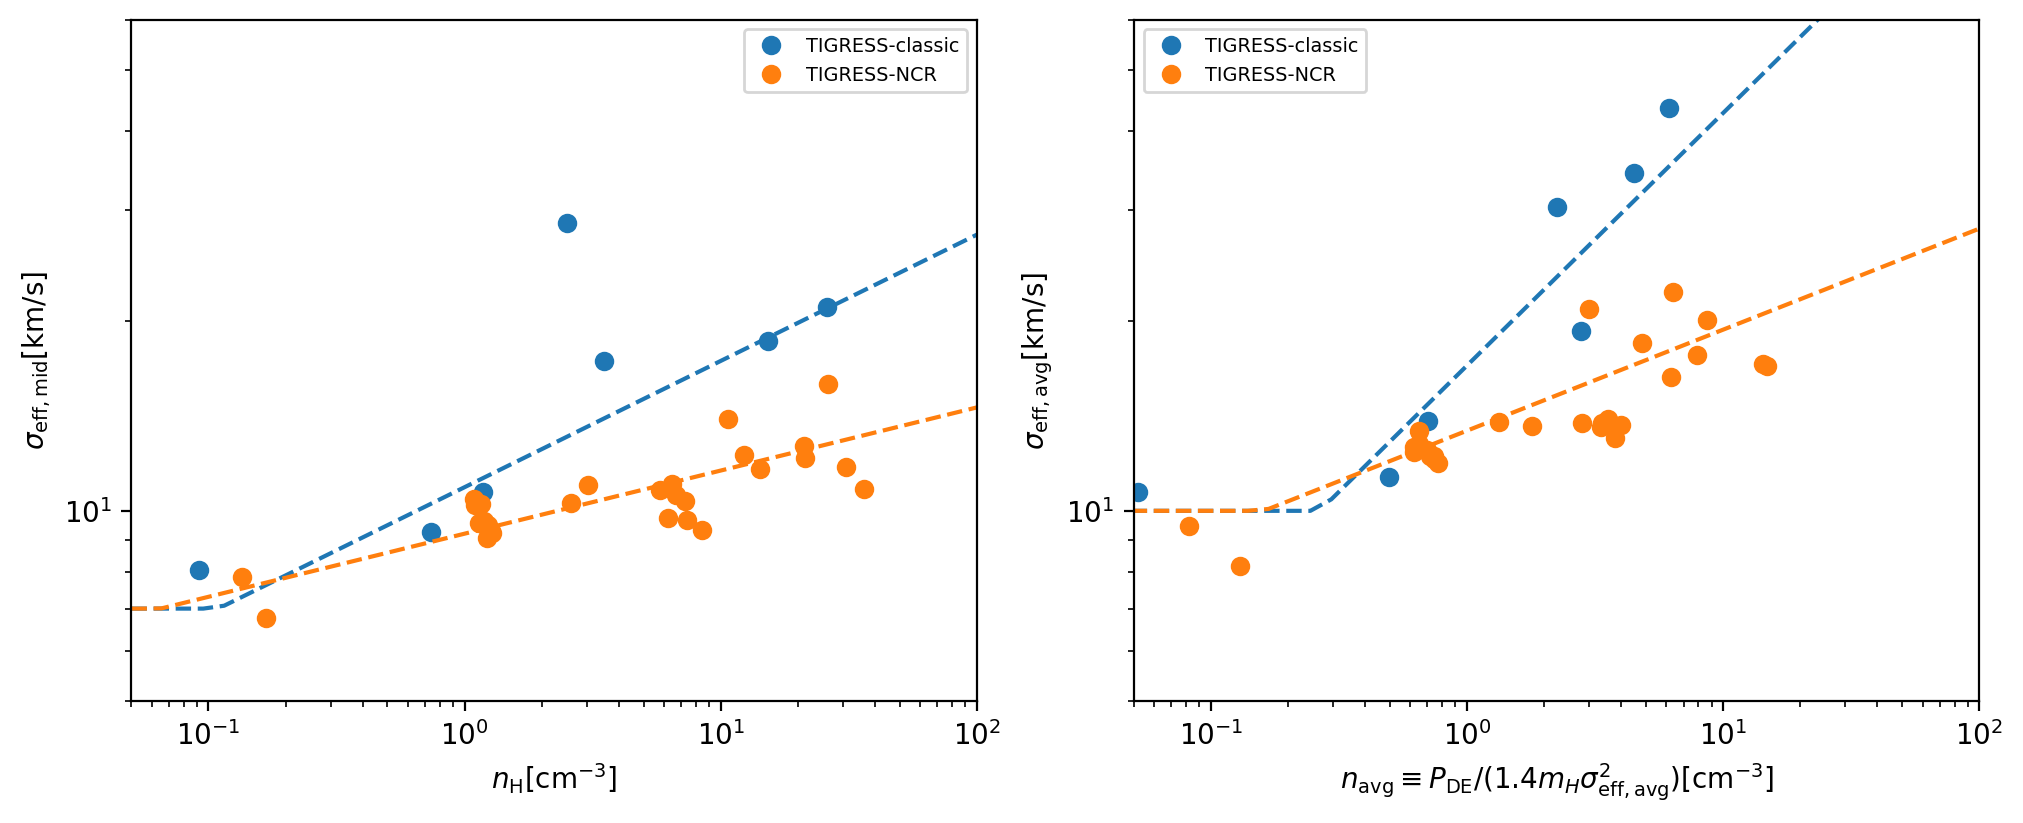

In [16]:
# sigma vs nH
fig,axes = plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
nHarr = np.logspace(-2,2)
sigfit = dict()
for model in ["tigress-classic-avg", "tigress-ncr-avg",
              "tigress-classic-mid", "tigress-ncr-mid"]:
    sigfit[model] = prfm.get_sigma_eff_n(nHarr,model=model)/1.e5

# midplane measures
plt.sca(axes[0])
plt.plot(classic_data["nmid"], classic_data["sigma_mid"], "o", label="TIGRESS-classic")
plt.plot(nHarr, sigfit["tigress-classic-mid"],
         ls="--", color="C0")
plt.plot(ncr_data["nmid"], ncr_data["sigma_mid"], "o", label="TIGRESS-NCR")
plt.plot(nHarr, sigfit["tigress-ncr-mid"],
         ls="--", color="C1")
plt.legend(fontsize="x-small")
plt.ylabel(r"$\sigma_{\rm eff,mid} [{\rm km/s}]$")
plt.xlabel(r"$n_{\rm H} [{\rm cm^{-3}}]$")
plt.yscale("log")
plt.xscale("log")
plt.xlim(0.05,100)
plt.ylim(5,60)

# mass-weighted averages
plt.sca(axes[1])
plt.plot(classic_data["navg"], classic_data["sigma_avg"], "o", label="TIGRESS-classic")
plt.plot(nHarr, sigfit["tigress-classic-avg"],
         ls="--", color="C0")
plt.plot(ncr_data["navg"], ncr_data["sigma_avg"], "o", label="TIGRESS-NCR")
plt.plot(nHarr, sigfit["tigress-ncr-avg"],
         ls="--", color="C1")
plt.legend(fontsize="x-small")
plt.ylabel(r"$\sigma_{\rm eff,avg} [{\rm km/s}]$")
plt.xlabel(r"$n_{\rm avg}\equiv P_{\rm DE}/(1.4m_H\sigma_{\rm eff,avg}^2) [{\rm cm^{-3}}]$")
plt.ylim(5,60)
plt.xlim(0.05,100)
plt.yscale("log")
plt.xscale("log")

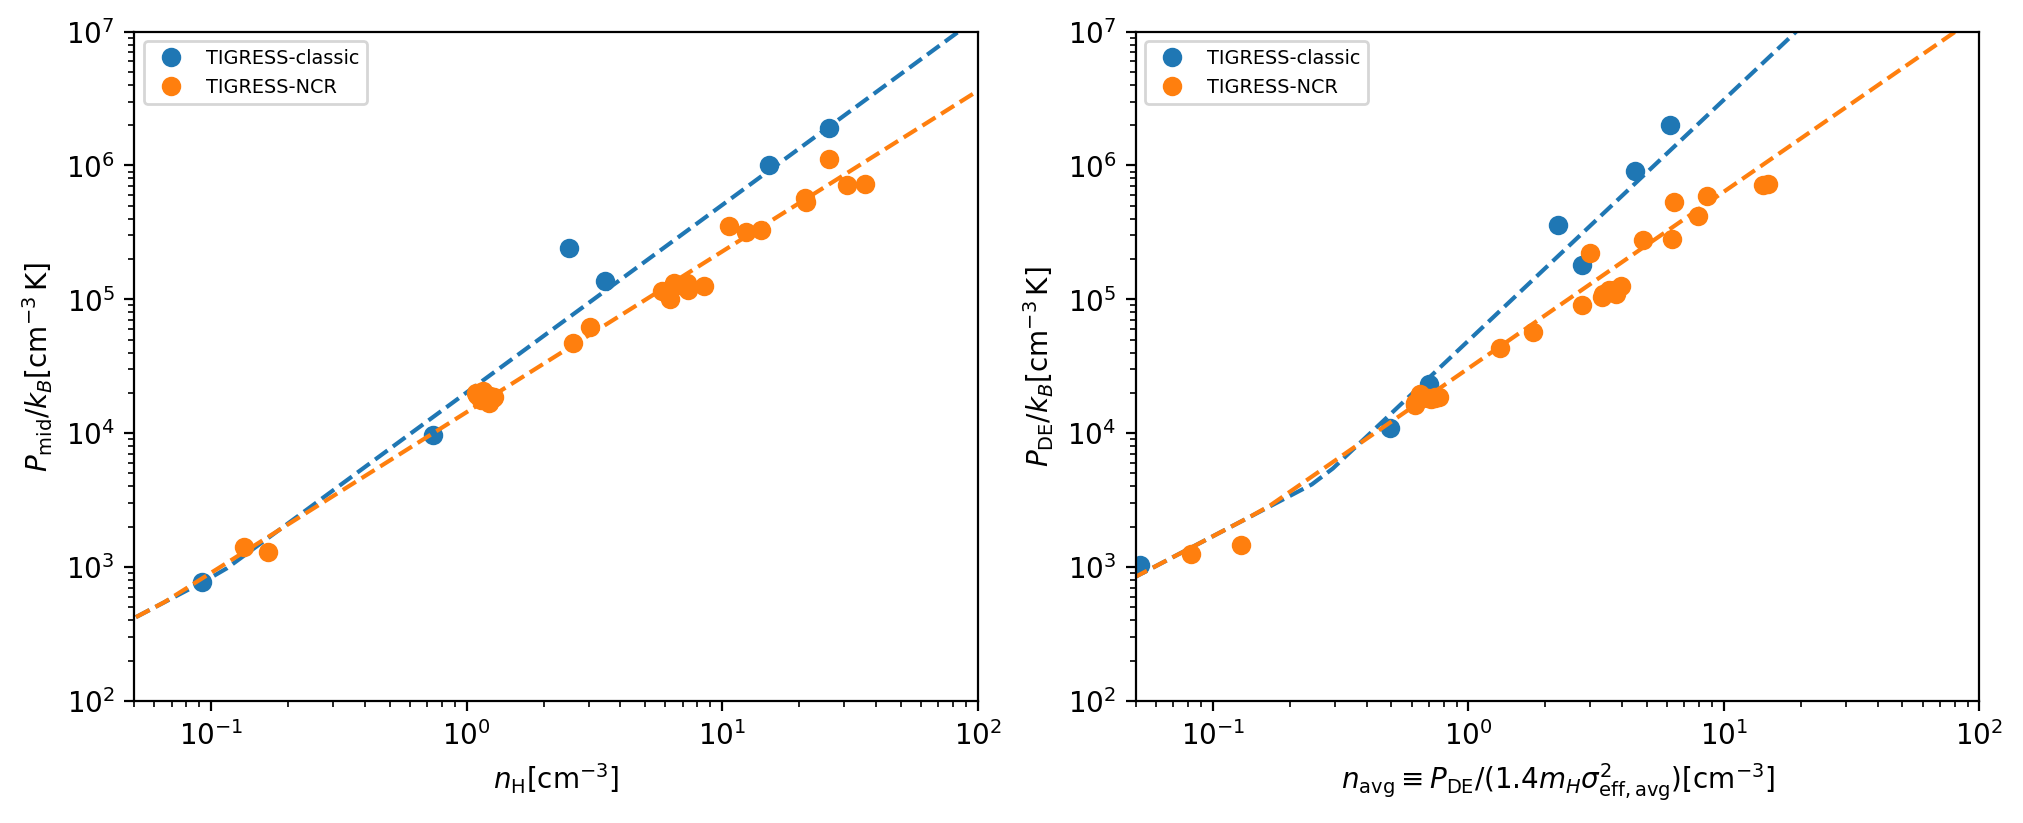

In [20]:
# effective EOS: P vs nH
fig,axes = plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
nHarr = np.logspace(-2,2)
Pfit = dict()
for model in ["tigress-classic-avg", "tigress-ncr-avg",
              "tigress-classic-mid", "tigress-ncr-mid"]:
    Pfit[model] = prfm.get_Peff_sigma(nHarr,model=model)/prfm.prfm._kbol_cgs

# midplane measures
plt.sca(axes[0])
plt.plot(classic_data["nmid"], classic_data["Pmid"], "o", label="TIGRESS-classic")
plt.plot(nHarr, Pfit["tigress-classic-mid"],
         ls="--", color="C0")
plt.plot(ncr_data["nmid"], ncr_data["Pmid"], "o", label="TIGRESS-NCR")
plt.plot(nHarr, Pfit["tigress-ncr-mid"],
         ls="--", color="C1")
plt.legend(fontsize="x-small")
plt.ylabel(r"$P_{\rm mid}/k_B [{\rm cm^{-3}\,K}]$")
plt.xlabel(r"$n_{\rm H} [{\rm cm^{-3}}]$")
plt.yscale("log")
plt.xscale("log")
plt.ylim(1.e2,1.e7)
plt.xlim(0.05,100)

# mass-weighted averages
plt.sca(axes[1])
plt.plot(classic_data["navg"], classic_data["PDE"], "o", label="TIGRESS-classic")
plt.plot(nHarr, Pfit["tigress-classic-avg"],
         ls="--", color="C0")
plt.plot(ncr_data["navg"], ncr_data["PDE"], "o", label="TIGRESS-NCR")
plt.plot(nHarr, Pfit["tigress-ncr-avg"],
         ls="--", color="C1")
plt.legend(fontsize="x-small")
plt.ylabel(r"$P_{\rm DE}/k_B [{\rm cm^{-3}\,K}]$")
plt.xlabel(r"$n_{\rm avg}\equiv P_{\rm DE}/(1.4m_H\sigma_{\rm eff,avg}^2) [{\rm cm^{-3}}]$")
plt.xlim(0.05,100)
plt.ylim(1.e2,1.e7)
plt.yscale("log")
plt.xscale("log")